In [1]:
pip install yfinance pandas numpy scipy matplotlib seaborn

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["AAPL", "MSFT", "AMZN", "JPM", "XOM"]

prices = yf.download(
    tickers,
    start="2018-01-01",
    end="2026-09-01",
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.dropna()

returns = prices.pct_change().dropna()

print(prices.head())
print(returns.head())
print(returns.describe())

Ticker           AAPL       AMZN        JPM       MSFT        XOM
Date                                                             
2018-01-02  40.232376  59.450500  85.516006  78.552032  57.811157
2018-01-03  40.225368  60.209999  85.603180  78.917580  58.946564
2018-01-04  40.412216  60.479500  86.829498  79.612183  59.028164
2018-01-05  40.872322  61.457001  86.272064  80.599236  58.980591
2018-01-08  40.720501  62.343498  86.399490  80.681488  59.245735
Ticker          AAPL      AMZN       JPM      MSFT       XOM
Date                                                        
2018-01-03 -0.000174  0.012775  0.001019  0.004654  0.019640
2018-01-04  0.004645  0.004476  0.014326  0.008802  0.001384
2018-01-05  0.011385  0.016163 -0.006420  0.012398 -0.000806
2018-01-08 -0.003715  0.014425  0.001477  0.001021  0.004495
2018-01-09 -0.000114  0.004676  0.005069 -0.000680 -0.004246
Ticker         AAPL         AMZN          JPM         MSFT          XOM
count   2176.000000  2176.000000  2176.

In [3]:
prices.to_csv("portfolio_prices.csv")
returns.to_csv("portfolio_returns.csv")

In [6]:
prices.shape

(2177, 5)

In [7]:
returns.shape

(2176, 5)

In [8]:
weights = np.array([
    0.30,  # AAPL
    0.20,  # MSFT
    0.20,  # AMZN
    0.15,  # JPM
    0.15   # XOM
])

assert np.isclose(weights.sum(), 1.0)

portfolio_returns = returns @ weights

portfolio_returns.name = "Portfolio_Return"

print(portfolio_returns.describe())

count    2176.000000
mean        0.000938
std         0.014380
min        -0.115656
25%        -0.005617
50%         0.001561
75%         0.008038
max         0.110015
Name: Portfolio_Return, dtype: float64


In [9]:
INITIAL_VALUE = 1_000_000

portfolio_pnl = portfolio_returns * INITIAL_VALUE

portfolio_pnl.name = "Portfolio_PnL"

print(portfolio_pnl.head())

Date
2018-01-03    6350.708101
2018-01-04    6681.722265
2018-01-05    7102.973345
2018-01-08    2893.379000
2018-01-09    1175.823673
Name: Portfolio_PnL, dtype: float64


In [10]:
def historical_var(returns, confidence=0.95, portfolio_value=1_000_000):
    percentile = (1 - confidence) * 100
    return -np.percentile(
        returns,
        percentile
    ) * portfolio_value

In [11]:
var_95 = historical_var(
    portfolio_returns.iloc[:250],
    confidence=0.95
)

var_99 = historical_var(
    portfolio_returns.iloc[:250],
    confidence=0.99
)

print("Historical VaR 95%:", var_95)
print("Historical VaR 99%:", var_99)

Historical VaR 95%: 25892.201765279144
Historical VaR 99%: 37710.992041339094


In [12]:
from scipy.stats import norm

def parametric_var(returns, weights, confidence=0.95,
                   portfolio_value=1_000_000):

    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    portfolio_mean = weights @ mean_returns
    portfolio_variance = weights @ cov_matrix @ weights
    portfolio_std = np.sqrt(portfolio_variance)

    z = norm.ppf(confidence)

    var = (
        z * portfolio_std - portfolio_mean
    ) * portfolio_value

    return var

In [13]:
window = returns.iloc[:250]

var_95 = parametric_var(
    window,
    weights,
    confidence=0.95
)

var_99 = parametric_var(
    window,
    weights,
    confidence=0.99
)

print("Variance-Covariance VaR 95%:", var_95)
print("Variance-Covariance VaR 99%:", var_99)

Variance-Covariance VaR 95%: 23478.255571236114
Variance-Covariance VaR 99%: 33287.60671911079


In [14]:
def monte_carlo_var(
    returns,
    weights,
    confidence=0.95,
    portfolio_value=1_000_000,
    simulations=50_000,
    random_seed=42
):

    np.random.seed(random_seed)

    mu = returns.mean().values
    cov = returns.cov().values

    simulated_returns = np.random.multivariate_normal(
        mean=mu,
        cov=cov,
        size=simulations
    )

    simulated_portfolio_returns = simulated_returns @ weights

    simulated_pnl = (
        simulated_portfolio_returns
        * portfolio_value
    )

    var = -np.percentile(
        simulated_pnl,
        (1 - confidence) * 100
    )

    return var

In [15]:
var_95_mc = monte_carlo_var(
    returns.iloc[:250],
    weights,
    confidence=0.95,
    simulations=50_000
)

var_99_mc = monte_carlo_var(
    returns.iloc[:250],
    weights,
    confidence=0.99,
    simulations=50_000
)

print("Monte Carlo VaR 95%:", var_95_mc)
print("Monte Carlo VaR 99%:", var_99_mc)

Monte Carlo VaR 95%: 23634.093094711774
Monte Carlo VaR 99%: 33376.87557633543


In [16]:
LOOKBACK = 250
PORTFOLIO_VALUE = 1_000_000

results = []

for i in range(LOOKBACK, len(returns) - 1):

    estimation_returns = returns.iloc[
        i - LOOKBACK:i
    ]

    next_day = returns.iloc[i]

    # Actual next-day portfolio return
    actual_return = next_day @ weights

    actual_pnl = (
        actual_return * PORTFOLIO_VALUE
    )

    # Historical
    hist_95 = historical_var(
        estimation_returns @ weights,
        confidence=0.95,
        portfolio_value=PORTFOLIO_VALUE
    )

    hist_99 = historical_var(
        estimation_returns @ weights,
        confidence=0.99,
        portfolio_value=PORTFOLIO_VALUE
    )

    # Variance-Covariance
    vc_95 = parametric_var(
        estimation_returns,
        weights,
        confidence=0.95,
        portfolio_value=PORTFOLIO_VALUE
    )

    vc_99 = parametric_var(
        estimation_returns,
        weights,
        confidence=0.99,
        portfolio_value=PORTFOLIO_VALUE
    )

    # Monte Carlo
    mc_95 = monte_carlo_var(
        estimation_returns,
        weights,
        confidence=0.95,
        portfolio_value=PORTFOLIO_VALUE,
        simulations=10_000,
        random_seed=42
    )

    mc_99 = monte_carlo_var(
        estimation_returns,
        weights,
        confidence=0.99,
        portfolio_value=PORTFOLIO_VALUE,
        simulations=10_000,
        random_seed=42
    )

    results.append({
        "Date": returns.index[i],
        "Actual_PnL": actual_pnl,
        "Historical_VaR_95": hist_95,
        "Historical_VaR_99": hist_99,
        "VC_VaR_95": vc_95,
        "VC_VaR_99": vc_99,
        "MC_VaR_95": mc_95,
        "MC_VaR_99": mc_99
    })

var_results = pd.DataFrame(results)

var_results.set_index("Date", inplace=True)

print(var_results.head())

              Actual_PnL  Historical_VaR_95  Historical_VaR_99     VC_VaR_95  \
Date                                                                           
2019-01-02  11387.943908       25892.201765       37710.992041  23478.255571   
2019-01-03 -45594.160079       25892.201765       37710.992041  23478.121840   
2019-01-04  42699.539792       26579.539128       40019.728094  24151.767764   
2019-01-07   7313.350816       26579.539128       40019.728094  24403.528333   
2019-01-08  10842.417723       26579.539128       40019.728094  24395.515472   

               VC_VaR_99     MC_VaR_95     MC_VaR_99  
Date                                                  
2019-01-02  33287.606719  23852.181928  32850.554481  
2019-01-03  33295.765673  23836.402585  32845.398158  
2019-01-04  34161.880376  24494.787631  33543.155686  
2019-01-07  34576.943499  24737.830291  33961.250125  
2019-01-08  34572.935872  24733.093308  33928.063026  


In [17]:
var_results["Hist_Breach_95"] = (
    -var_results["Actual_PnL"]
    > var_results["Historical_VaR_95"]
)

var_results["VC_Breach_95"] = (
    -var_results["Actual_PnL"]
    > var_results["VC_VaR_95"]
)

var_results["MC_Breach_95"] = (
    -var_results["Actual_PnL"]
    > var_results["MC_VaR_95"]
)

In [18]:
var_results["Hist_Breach_99"] = (
    -var_results["Actual_PnL"]
    > var_results["Historical_VaR_99"]
)

var_results["VC_Breach_99"] = (
    -var_results["Actual_PnL"]
    > var_results["VC_VaR_99"]
)

var_results["MC_Breach_99"] = (
    -var_results["Actual_PnL"]
    > var_results["MC_VaR_99"]
)

In [19]:
from scipy.stats import chi2

def kupiec_pof_test(breaches, confidence):

    breaches = np.asarray(breaches).astype(int)

    n = len(breaches)
    x = breaches.sum()

    p = 1 - confidence

    if x == 0:
        likelihood_ratio = (
            -2 * (
                n * np.log(1 - p)
            )
            + 2 * (
                n * np.log(1)
            )
        )
    elif x == n:
        likelihood_ratio = (
            -2 * (
                n * np.log(p)
            )
            + 2 * (
                n * np.log(x / n)
            )
        )
    else:
        p_hat = x / n

        lr = (
            2 * (
                x * np.log(p_hat / p)
                +
                (n - x)
                * np.log(
                    (1 - p_hat) / (1 - p)
                )
            )
        )

        likelihood_ratio = lr

    p_value = 1 - chi2.cdf(
        likelihood_ratio,
        df=1
    )

    return {
        "Observations": n,
        "Exceptions": x,
        "Exception_Rate": x / n,
        "Expected_Rate": p,
        "LR": likelihood_ratio,
        "p_value": p_value
    }

In [20]:
kupiec_pof_test(
    var_results["Hist_Breach_95"],
    confidence=0.95
)

{'Observations': 1925,
 'Exceptions': np.int64(99),
 'Exception_Rate': np.float64(0.05142857142857143),
 'Expected_Rate': 0.050000000000000044,
 'LR': np.float64(0.08197105216323664),
 'p_value': np.float64(0.774643861325197)}

In [21]:
def christoffersen_independence_test(breaches):

    breaches = np.asarray(breaches).astype(int)

    n00 = n01 = n10 = n11 = 0

    for i in range(1, len(breaches)):

        previous = breaches[i - 1]
        current = breaches[i]

        if previous == 0 and current == 0:
            n00 += 1
        elif previous == 0 and current == 1:
            n01 += 1
        elif previous == 1 and current == 0:
            n10 += 1
        elif previous == 1 and current == 1:
            n11 += 1

    # Transition probabilities
    pi01 = (
        n01 / (n00 + n01)
        if (n00 + n01) > 0
        else 0
    )

    pi11 = (
        n11 / (n10 + n11)
        if (n10 + n11) > 0
        else 0
    )

    total_exceptions = n01 + n11
    total_non_exceptions = n00 + n10

    pi = (
        total_exceptions
        / (total_exceptions + total_non_exceptions)
    )

    # Restricted likelihood
    log_l0 = 0

    if 0 < pi < 1:
        log_l0 = (
            (n00 + n10) * np.log(1 - pi)
            +
            (n01 + n11) * np.log(pi)
        )

    # Unrestricted likelihood
    log_l1 = 0

    if 0 < pi01 < 1:
        log_l1 += (
            n00 * np.log(1 - pi01)
            +
            n01 * np.log(pi01)
        )

    if 0 < pi11 < 1:
        log_l1 += (
            n10 * np.log(1 - pi11)
            +
            n11 * np.log(pi11)
        )

    lr_ind = -2 * (log_l0 - log_l1)

    p_value = 1 - chi2.cdf(
        lr_ind,
        df=1
    )

    return {
        "n00": n00,
        "n01": n01,
        "n10": n10,
        "n11": n11,
        "LR_independence": lr_ind,
        "p_value": p_value
    }

In [22]:
christoffersen_independence_test(
    var_results["Hist_Breach_95"]
)

{'n00': 1736,
 'n01': 89,
 'n10': 89,
 'n11': 10,
 'LR_independence': np.float64(4.213948071278196),
 'p_value': np.float64(0.040092918391318344)}

In [23]:
models = {
    "Historical": "Hist",
    "Variance-Covariance": "VC",
    "Monte Carlo": "MC"
}

backtest_results = []

for model_name, prefix in models.items():

    for confidence in [0.95, 0.99]:

        level = int(confidence * 100)

        breach_col = (
            f"{prefix}_Breach_{level}"
        )

        breaches = var_results[breach_col]

        kupiec = kupiec_pof_test(
            breaches,
            confidence
        )

        christoffersen = (
            christoffersen_independence_test(
                breaches
            )
        )

        backtest_results.append({

            "Model": model_name,

            "Confidence": confidence,

            "Exceptions":
                kupiec["Exceptions"],

            "Exception Rate":
                kupiec["Exception_Rate"],

            "Expected Rate":
                kupiec["Expected_Rate"],

            "Kupiec LR":
                kupiec["LR"],

            "Kupiec p-value":
                kupiec["p_value"],

            "Christoffersen LR":
                christoffersen[
                    "LR_independence"
                ],

            "Christoffersen p-value":
                christoffersen["p_value"]
        })

backtest_df = pd.DataFrame(
    backtest_results
)

print(backtest_df)

                 Model  Confidence  Exceptions  Exception Rate  Expected Rate  \
0           Historical        0.95          99        0.051429           0.05   
1           Historical        0.99          30        0.015584           0.01   
2  Variance-Covariance        0.95         104        0.054026           0.05   
3  Variance-Covariance        0.99          45        0.023377           0.01   
4          Monte Carlo        0.95         105        0.054545           0.05   
5          Monte Carlo        0.99          46        0.023896           0.01   

   Kupiec LR  Kupiec p-value  Christoffersen LR  Christoffersen p-value  
0   0.081971    7.746439e-01           4.213948                0.040093  
1   5.181932    2.282293e-02           6.536485                0.010568  
2   0.640811    4.234174e-01           4.627175                0.031469  
3  25.273134    4.975916e-07          16.338447                0.000053  
4   0.814322    3.668455e-01           4.393290               

In [24]:
lookbacks = [125, 250, 500]

sensitivity_results = []

for lookback in lookbacks:

    for confidence in [0.95, 0.99]:

        values = []

        for i in range(
            lookback,
            len(returns) - 1
        ):

            window = returns.iloc[
                i-lookback:i
            ]

            var = historical_var(
                window @ weights,
                confidence=confidence,
                portfolio_value=1_000_000
            )

            values.append(var)

        sensitivity_results.append({
            "Lookback": lookback,
            "Confidence": confidence,
            "Average_VaR": np.mean(values),
            "Median_VaR": np.median(values),
            "Max_VaR": np.max(values)
        })

sensitivity_df = pd.DataFrame(
    sensitivity_results
)

print(sensitivity_df)

   Lookback  Confidence   Average_VaR    Median_VaR       Max_VaR
0       125        0.95  20862.055464  17168.425339  44852.925172
1       125        0.99  35490.676516  28338.261412  92507.505530
2       250        0.95  22440.877891  20437.242843  39834.762170
3       250        0.99  38460.492289  37604.487193  74826.207855
4       500        0.95  22620.223113  23159.035055  33776.562801
5       500        0.99  38328.196754  41401.830710  47597.831720


In [25]:
weight_scenarios = {
    "Equal Weight": np.array([
        .20, .20, .20, .20, .20
    ]),

    "Tech Heavy": np.array([
        .30, .30, .20, .10, .10
    ]),

    "Defensive": np.array([
        .10, .10, .15, .30, .35
    ])
}

In [26]:
weight_results = []

for scenario, scenario_weights in weight_scenarios.items():

    var = parametric_var(
        returns.iloc[-250:],
        scenario_weights,
        confidence=0.99,
        portfolio_value=1_000_000
    )

    weight_results.append({
        "Scenario": scenario,
        "VaR_99": var
    })

weight_df = pd.DataFrame(weight_results)

print(weight_df)

       Scenario        VaR_99
0  Equal Weight  19645.074478
1    Tech Heavy  22405.863403
2     Defensive  20048.574499


In [27]:
correlation_matrix = returns.corr()

print(correlation_matrix)

Ticker      AAPL      AMZN       JPM      MSFT       XOM
Ticker                                                  
AAPL    1.000000  0.555048  0.416858  0.643904  0.279532
AMZN    0.555048  1.000000  0.313145  0.652407  0.142648
JPM     0.416858  0.313145  1.000000  0.409649  0.507016
MSFT    0.643904  0.652407  0.409649  1.000000  0.226334
XOM     0.279532  0.142648  0.507016  0.226334  1.000000


In [28]:
covariance_matrix = returns.cov()

print(covariance_matrix)

Ticker      AAPL      AMZN       JPM      MSFT       XOM
Ticker                                                  
AAPL    0.000370  0.000232  0.000145  0.000227  0.000102
AMZN    0.000232  0.000474  0.000123  0.000261  0.000059
JPM     0.000145  0.000123  0.000325  0.000136  0.000173
MSFT    0.000227  0.000261  0.000136  0.000337  0.000079
XOM     0.000102  0.000059  0.000173  0.000079  0.000358


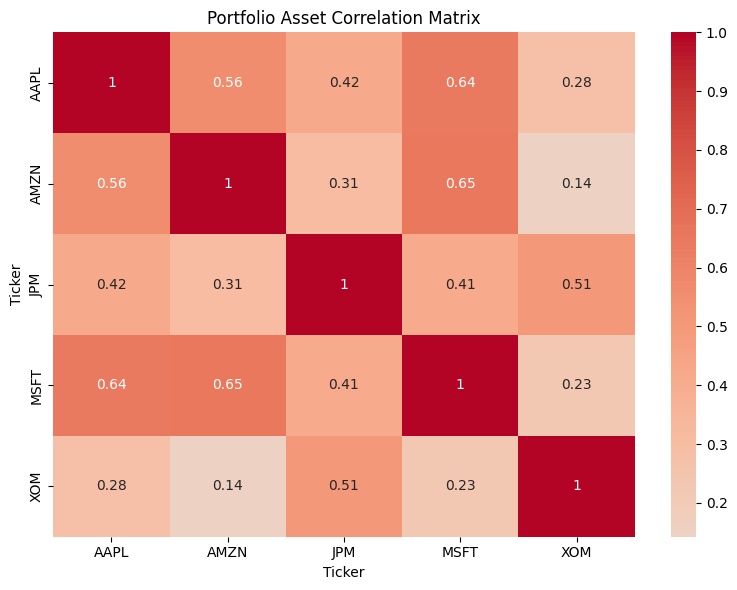

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Portfolio Asset Correlation Matrix")
plt.tight_layout()
plt.show()

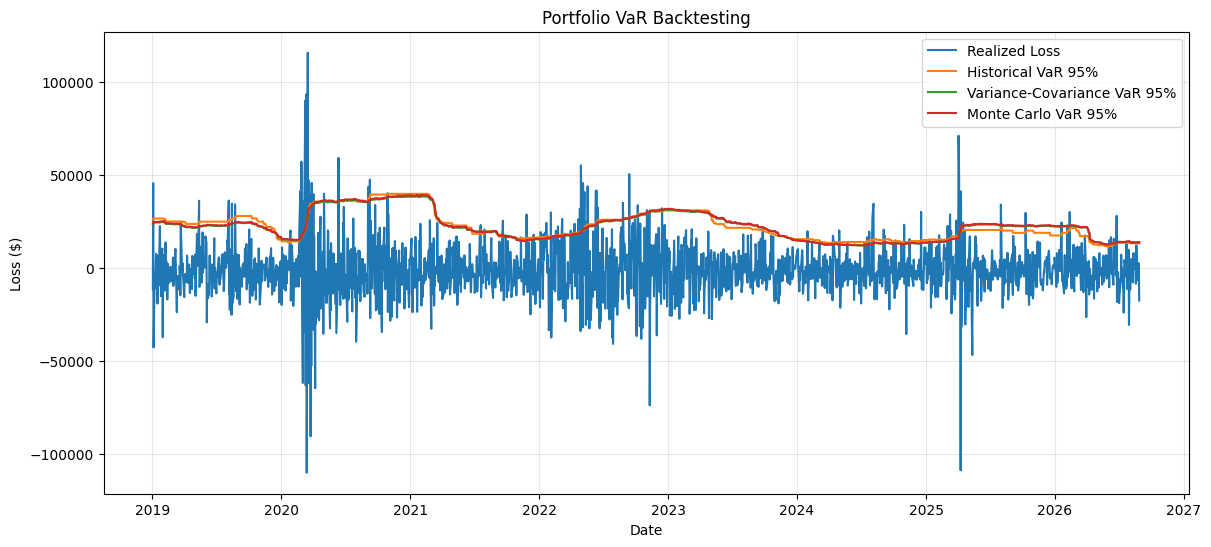

In [30]:
plt.figure(figsize=(14, 6))

plt.plot(
    var_results.index,
    -var_results["Actual_PnL"],
    label="Realized Loss"
)

plt.plot(
    var_results.index,
    var_results["Historical_VaR_95"],
    label="Historical VaR 95%"
)

plt.plot(
    var_results.index,
    var_results["VC_VaR_95"],
    label="Variance-Covariance VaR 95%"
)

plt.plot(
    var_results.index,
    var_results["MC_VaR_95"],
    label="Monte Carlo VaR 95%"
)

plt.title("Portfolio VaR Backtesting")
plt.ylabel("Loss ($)")
plt.xlabel("Date")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [31]:
exception_summary = pd.DataFrame({

    "Historical 95%":
        var_results["Hist_Breach_95"].sum(),

    "Historical 99%":
        var_results["Hist_Breach_99"].sum(),

    "VC 95%":
        var_results["VC_Breach_95"].sum(),

    "VC 99%":
        var_results["VC_Breach_99"].sum(),

    "Monte Carlo 95%":
        var_results["MC_Breach_95"].sum(),

    "Monte Carlo 99%":
        var_results["MC_Breach_99"].sum()

}, index=["Exceptions"])

print(exception_summary)

            Historical 95%  Historical 99%  VC 95%  VC 99%  Monte Carlo 95%  \
Exceptions              99              30     104      45              105   

            Monte Carlo 99%  
Exceptions               46  


In [34]:
latest = var_results.iloc[-1]

print("Latest Portfolio P&L:",
      latest["Actual_PnL"])

print("Historical VaR 95%:",
      latest["Historical_VaR_95"])

print("VC VaR 95%:",
      latest["VC_VaR_95"])

print("Monte Carlo VaR 95%:",
      latest["MC_VaR_95"])

Latest Portfolio P&L: 17514.11188330174
Historical VaR 95%: 13267.62663211386
VC VaR 95%: 13793.741232810864
Monte Carlo VaR 95%: 13764.75708569491
